In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 生成不同tau_ou的npy

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 20
c2tsc_list = [0.8]
scale2_list = [0.0013]
#tauou_list = np.linspace(5,20,16)
tauou_list = np.linspace(3,42,40)

print("c2tsc_list:", c2tsc_list)
print("scale2_list:", scale2_list)
print("tauou__list:", tauou_list)

# 创建保存目录
os.makedirs("data/raw_data_explore_tauou", exist_ok=True)

# ========== 统计已完成的文件 ==========
existing_files = set()
for f in os.listdir("data/raw_data_explore_tauou"):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

# ========== 主循环 ==========
for c2tsc in c2tsc_list:
    for tauou in tauou_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2_list[0]:.4f}_tauou_{tauou:.4f}_seed_{seed}.npy"
            save_path = f"data/raw_data_explore_tauou/{filename}"
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                print(f"跳过已存在的文件: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2_list[0]
            params["tau_ou"] = tauou
            
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2_list[0],
                "tauou": tauou,
                "seed": seed
            })
            print(f"Saved: c2tsc={c2tsc:.4f}, scale2={scale2_list[0]:.4f}, tauou={tauou:.4f}, seed={seed}")

# ========== 完成统计 ==========
final_files = set(os.listdir("data/raw_data_explore_tauou"))
print(f"\n完成！共 {len(final_files)} 个文件")

c2tsc_list: [0.8]
scale2_list: [0.0013]
tauou__list: [ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20.
 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38.
 39. 40. 41. 42.]
已存在 51 个文件，将跳过它们
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_1.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_2.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_3.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_4.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_5.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_6.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_7.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_8.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_9.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_10.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_11.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0.0013_tauou_3.0000_seed_12.npy
跳过已存在的文件: c2tsc_0.8000_scale2_0

In [3]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/tauou for20251128_11:10isdone')


### spindles for tau_ou anlysis (spindles_tau_ou_explore_valid_limited.csv)
- c2tsc = 0.8; scale2 = 0.0013
- tau_ou -> fast/slow spindles

In [7]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
remove_edges_samples = 20000  # 去掉前后各 20000 个采样点（2秒）

# 慢波滤波参数
SW = {"low_freq": None, "high_freq": 3.0}

# 振幅阈值参数（用于掩码噪声片段）
amplitude_threshold = 2  # mV，只保留包络大于此值的片段

# ========== 限定 tau_ou 范围 ==========
tau_ou_min = 3
tau_ou_max = 42

def get_phase_and_envelope(signal, filter_args, pad=None):
    """返回相位、滤波后的信号和包络（用于振幅掩码）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(
            how_much=pad, in_seconds=True, padding_type="reflect", side="both"
        )
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    
    # 计算包络（瞬时振幅）
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    
    return phase.data.values, filtered, envelope

# ========== 批量处理 ==========
all_spindles = []
file_list = glob.glob("data/raw_data_explore_tauou/*.npy")
print(f"找到 {len(file_list)} 个文件")
print(f"限定 tau_ou 范围: [{tau_ou_min}, {tau_ou_max}]")

for file_path in file_list:
    # 解析文件名，提取参数
    file_path = file_path.replace("\\", "/")
    filename = file_path.split("/")[-1]
    parts = filename.replace(".npy", "").split("_")
    
    # 根据文件名格式解析: c2tsc_{val}_scale2_{val}_tause_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    tau_ou = float(parts[5])
    seed = int(parts[7])
    
    # 只处理 tau_ou 在指定范围内的文件
    if not (tau_ou_min <= tau_ou <= tau_ou_max):
        continue
    
    print(f"Processing: c2tsc={c2tsc:.4f}, scale2={scale2:.4f}, tau_ou={tau_ou:.4f}, seed={seed}")
    
    # 加载数据
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    # 计算时间边界（采样点）
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    # 只保留中间部分用于相位计算
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_t_mid = V_t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    # 构建 neurolib Signal 对象
    results_df = pd.DataFrame(
        {"ALN": V_e_mid, "TCR": V_t_mid},
        index=t_mid / sf,
    )
    results_df.index.name = "time"
    
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    # 计算慢波相位、滤波信号和包络
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    # ========== 振幅掩码：将小振幅片段的相位设为 NaN ==========
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    masked_ratio = np.sum(~mask_amplitude) / len(mask_amplitude) * 100
    print(f"  振幅掩码: 保留 {mask_amplitude.sum()}/{len(mask_amplitude)} 点 ({100-masked_ratio:.1f}%)")
    
    # ========== 处理纺锤波的通用函数 ==========
    def process_spindles(sp, spindle_type):
        """处理纺锤波检测结果，返回列表"""
        results = []
        if sp is None:
            return results
        
        df = sp.summary()
        for _, row in df.iterrows():
            start_time = row["Start"]
            peak_time = row["Peak"]
            end_time = row["End"]
            
            # 转换为采样点索引
            start_idx_sample = int(start_time * sf)
            peak_idx_sample = int(peak_time * sf)
            end_idx_sample = int(end_time * sf)
            
            # 检查纺锤波是否完全在有效窗口内
            if not (t_min <= start_idx_sample <= t_max and 
                    t_min <= end_idx_sample <= t_max):
                continue
            
            # 找到在中间信号中的索引
            start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
            peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
            end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
            
            # 获取相位（使用掩码后的相位，小振幅处为 NaN）
            phase_start = slow_phase_masked[start_idx]
            phase_peak = slow_phase_masked[peak_idx]
            phase_end = slow_phase_masked[end_idx]
            
            results.append({
                "c2tsc": c2tsc,
                "scale2": scale2,
                "tau_ou": tau_ou,
                "seed": seed,
                "type": spindle_type,
                "start": start_time,
                "peak_time": peak_time,
                "end": end_time,
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
                "phase_at_start": phase_start,
                "phase_at_peak": phase_peak,
                "phase_at_end": phase_end,
                "envelope_at_start": envelope[start_idx],
                "envelope_at_peak": envelope[peak_idx],
                "envelope_at_end": envelope[end_idx],
                "masked": np.isnan(phase_peak),
            })
        return results
    
    # 检测快纺锤波（12-16 Hz）
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast"))
    
    # 检测慢纺锤波（8-12 Hz）
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow"))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv("data/analysis_data/spindles_tau_ou_explore_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"其中相位被掩码的: {(result_df['masked'].sum())} / {len(result_df)}")

# 只保留相位有效的行
result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv("data/analysis_data/spindles_tau_ou_explore_valid_limited.csv", index=False)
print(f"相位有效（未被掩码）的纺锤波: {len(result_df_valid)} 个")

print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.4f} ~ {result_df['scale2'].max():.4f}")
print(f"  tau_ou: {result_df['tau_ou'].min():.4f} ~ {result_df['tau_ou'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 800 个文件
限定 tau_ou 范围: [3, 42]
Processing: c2tsc=0.8000, scale2=0.0013, tau_ou=10.0000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 220144/260001 点 (84.7%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=7, 慢=8
Processing: c2tsc=0.8000, scale2=0.0013, tau_ou=10.0000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 223535/260001 点 (86.0%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=5, 慢=8
Processing: c2tsc=0.8000, scale2=0.0013, tau_ou=10.0000, seed=11
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 208696/260001 点 (80.3%)


...


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 217838/260001 点 (83.8%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=9, 慢=9
Processing: c2tsc=0.8000, scale2=0.0013, tau_ou=9.0000, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)

  振幅掩码: 保留 212417/260001 点 (81.7%)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=8, 慢=8

总共检测到 10509 个纺锤波
其中相位被掩码的: 1018 / 10509
相位有效（未被掩码）的纺锤波: 9491 个

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.0013 ~ 0.0013
  tau_ou: 3.0000 ~ 42.0000

前几行:
   c2tsc  scale2  tau_ou  seed  type    start  peak_time      end  duration  \
0    0.8  0.0013    10.0     1  fast   2.8320     2.9262   3.7673    0.9353   
1    0.8  0.0013    10.0     1  fast  14.6477    14.7706  15.5097    0.8620   
2    0.8  0.0013    10.0     1  fast  18.6581    18.8549  19.6887    1.0306   
3    0.8  0.0013    10.0     1  fast  20.8837    21.1034  21.6969    0.8132   
4    0.8  0.0013    10.0     1  fast  23.5336    24.4004  24.6010    1.0674   

   frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  \
0  12.961576   3.522183        1.233453            NaN     -0.883845   
1  13.069054   4.344866       -2.031445      -0.935398     -1.000934   
2  12.840822   4.632072        1.479462       0.734371     -0.316989   
3  11.753225   3.699629        1.730467      -0.183160      1.945478

### 为tau_ou画图，为什么后期全部不变？

tau_ou 值: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0]


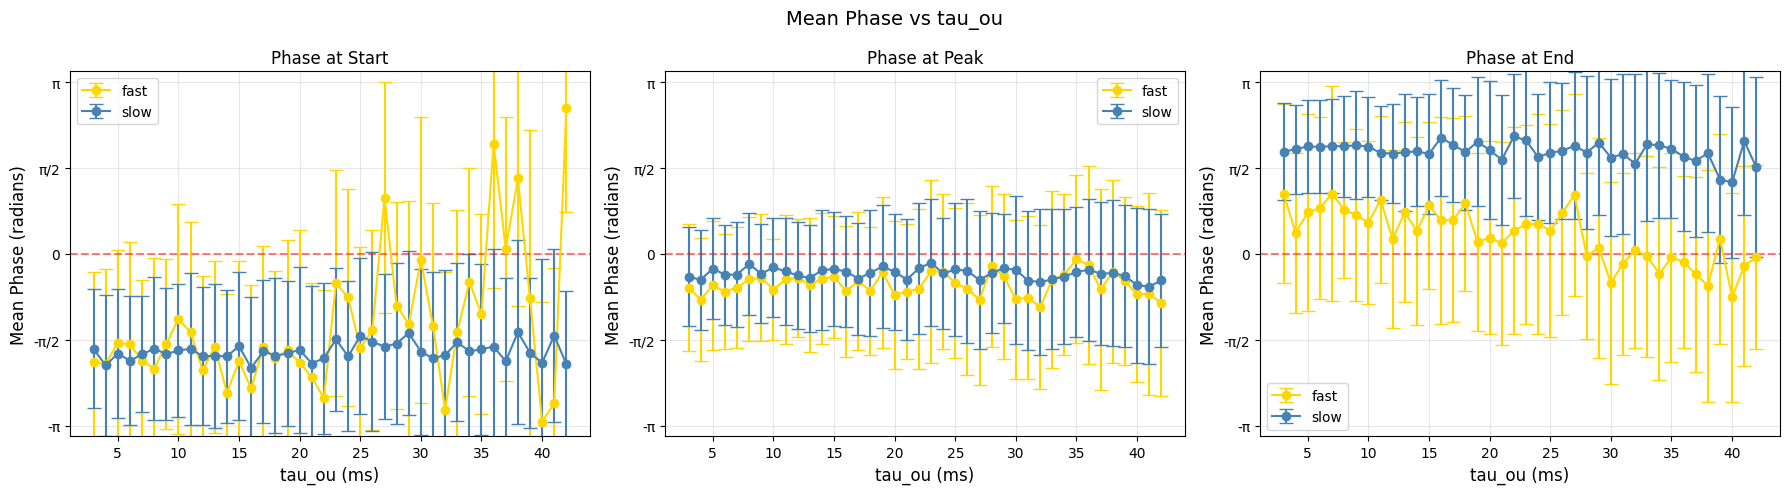

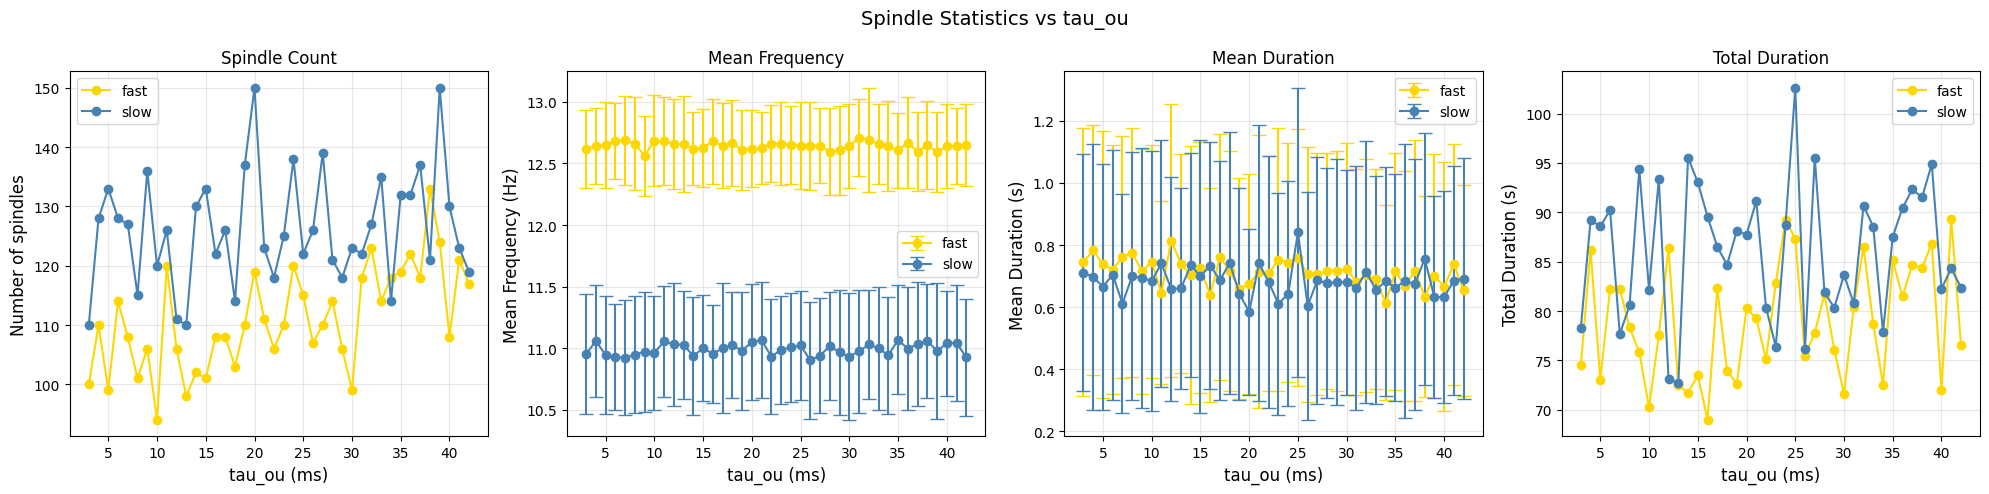


统计摘要

FAST 纺锤波:
  总数量: 4440
  tau_ou=3.00: n=100, mean_freq=12.62±0.32Hz, mean_dur=0.7452s, total_dur=74.5197s, mean_phase=-0.616 rad
  tau_ou=4.00: n=110, mean_freq=12.64±0.31Hz, mean_dur=0.7835s, total_dur=86.1818s, mean_phase=-0.837 rad
  tau_ou=5.00: n= 99, mean_freq=12.65±0.35Hz, mean_dur=0.7379s, total_dur=73.0524s, mean_phase=-0.578 rad
  tau_ou=6.00: n=114, mean_freq=12.68±0.31Hz, mean_dur=0.7214s, total_dur=82.2427s, mean_phase=-0.690 rad
  tau_ou=7.00: n=108, mean_freq=12.69±0.36Hz, mean_dur=0.7616s, total_dur=82.2495s, mean_phase=-0.617 rad
  tau_ou=8.00: n=101, mean_freq=12.66±0.38Hz, mean_dur=0.7756s, total_dur=78.3349s, mean_phase=-0.465 rad
  tau_ou=9.00: n=106, mean_freq=12.56±0.32Hz, mean_dur=0.7152s, total_dur=75.8146s, mean_phase=-0.436 rad
  tau_ou=10.00: n= 94, mean_freq=12.68±0.37Hz, mean_dur=0.7471s, total_dur=70.2277s, mean_phase=-0.652 rad
  tau_ou=11.00: n=120, mean_freq=12.68±0.36Hz, mean_dur=0.6462s, total_dur=77.5487s, mean_phase=-0.469 rad
  tau_ou=12.00:

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_tau_ou_explore_valid_limited.csv")

# ========== 参数设置 ==========
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

# 获取唯一的 tau_ou 值
tau_ou_values = sorted(df['tau_ou'].unique())
print(f"tau_ou 值: {tau_ou_values}")

# ========== 定义圆形统计函数 ==========
def circular_stats(phases):
    """返回平均相位、圆形标准差、样本数"""
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 图1：平均相位随 tau_ou 的变化 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means = []
        stds = []
        tau_vals = []
        for tau in tau_ou_values:
            phases = subset[subset['tau_ou'] == tau][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                tau_vals.append(tau)
        if len(tau_vals) > 0:
            ax.errorbar(tau_vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel('tau_ou (ms)', fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle('Mean Phase vs tau_ou', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/mean_phase_vs_tau_ou.png", dpi=150)
plt.show()

# ========== 图2：四张汇总图并排（数量、平均频率、平均时长、总时长）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：数量
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    counts = subset.groupby('tau_ou').size()
    ax.plot(counts.index, counts.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_ou (ms)', fontsize=12)
ax.set_ylabel('Number of spindles', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_freq = subset.groupby('tau_ou')['frequency'].mean()
    std_freq = subset.groupby('tau_ou')['frequency'].std()
    ax.errorbar(mean_freq.index, mean_freq.values, yerr=std_freq.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_ou (ms)', fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    mean_duration = subset.groupby('tau_ou')['duration'].mean()
    std_duration = subset.groupby('tau_ou')['duration'].std()
    ax.errorbar(mean_duration.index, mean_duration.values, yerr=std_duration.values,
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_ou (ms)', fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    total_duration = subset.groupby('tau_ou')['duration'].sum()
    ax.plot(total_duration.index, total_duration.values, 'o-', color=colors[spindle_type], label=spindle_type)
ax.set_xlabel('tau_ou (ms)', fontsize=12)
ax.set_ylabel('Total Duration (s)', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Spindle Statistics vs tau_ou', fontsize=14)
plt.tight_layout()
# plt.savefig("analysis_data/spindle_stats_vs_tau_ou_combined.png", dpi=150)
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = df[df['type'] == spindle_type]
    print(f"\n{spindle_type.upper()} 纺锤波:")
    print(f"  总数量: {len(subset)}")
    
    for tau_val in tau_ou_values:
        sub = subset[subset['tau_ou'] == tau_val]
        if len(sub) > 0:
            n_spindles = len(sub)
            mean_dur = sub['duration'].mean()
            total_dur = sub['duration'].sum()
            mean_freq = sub['frequency'].mean()
            std_freq = sub['frequency'].std()
            # 相位统计
            phases = sub['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  tau_ou={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, mean_phase={mean_phase:6.3f} rad")
            else:
                print(f"  tau_ou={tau_val:.2f}: n={n_spindles:3d}, mean_freq={mean_freq:.2f}±{std_freq:.2f}Hz, mean_dur={mean_dur:.4f}s, total_dur={total_dur:.4f}s, no valid phase")

tau_ou 值: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0]


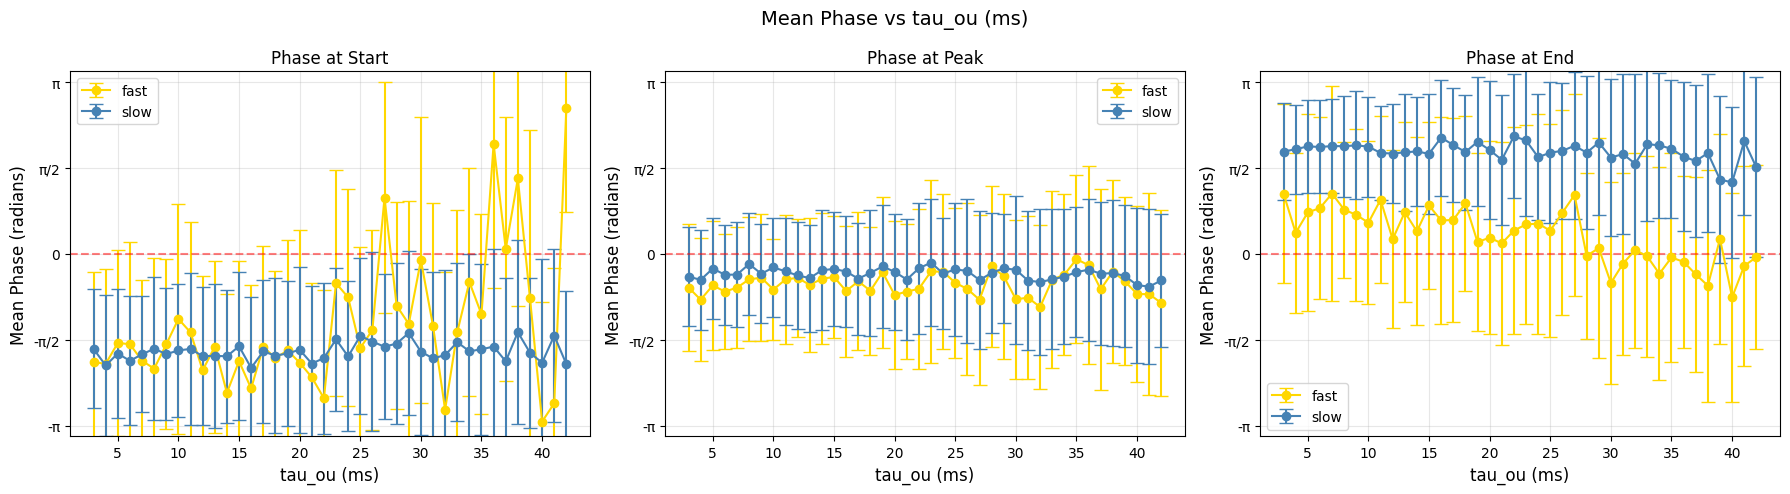


按 seed 统计后的结果示例:
   tau_ou  seed  type  total_duration  count  mean_freq  std_freq  \
0     3.0     1  fast          5.6679      6  12.444166  0.152321   
1     3.0     1  slow          7.2279      9  11.051506  0.619434   
2     3.0     2  fast          2.9607      4  12.519235  0.257033   
3     3.0     2  slow          2.6499      5  11.085898  0.348486   
4     3.0     3  fast          1.8196      2  12.435491  0.506975   

   mean_duration  std_duration  
0       0.944650      0.566331  
1       0.803100      0.426190  
2       0.740175      0.451780  
3       0.529980      0.220173  
4       0.909800      0.506996  

汇总统计示例:
   tau_ou  type  mean_total_duration  std_total_duration  mean_count  \
0     3.0  fast             3.725985            1.624541        5.00   
1     3.0  slow             3.913925            1.521644        5.50   
2     4.0  fast             4.309090            1.189576        5.50   
3     4.0  slow             4.460370            1.225080        6.40   


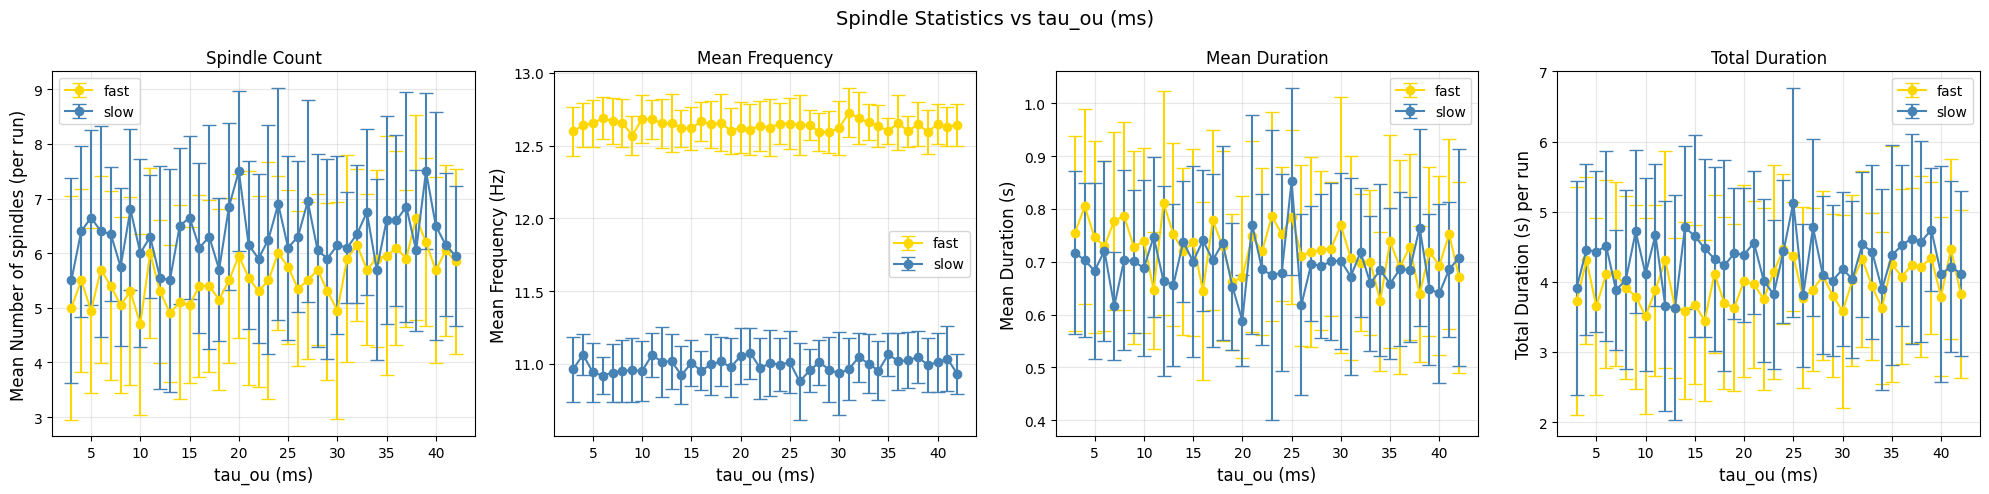


统计摘要（每个 seed 先统计，再对 seed 平均）

FAST 纺锤波:
  tau_ou=3.00: seeds=20, count=5.0±2.1, total_dur=3.73±1.62s, freq=12.60±0.17Hz, dur=0.754±0.185s, phase=-0.616±1.156rad
  tau_ou=4.00: seeds=20, count=5.5±1.7, total_dur=4.31±1.19s, freq=12.64±0.15Hz, dur=0.805±0.184s, phase=-0.837±1.132rad
  tau_ou=5.00: seeds=20, count=5.0±1.5, total_dur=3.65±1.26s, freq=12.65±0.16Hz, dur=0.746±0.182s, phase=-0.578±1.185rad
  tau_ou=6.00: seeds=20, count=5.7±1.7, total_dur=4.11±1.34s, freq=12.69±0.14Hz, dur=0.730±0.161s, phase=-0.690±1.060rad
  tau_ou=7.00: seeds=20, count=5.4±1.7, total_dur=4.11±1.31s, freq=12.67±0.16Hz, dur=0.778±0.168s, phase=-0.617±1.113rad
  tau_ou=8.00: seeds=20, count=5.0±1.6, total_dur=3.92±1.30s, freq=12.66±0.16Hz, dur=0.787±0.178s, phase=-0.465±1.134rad
  tau_ou=9.00: seeds=20, count=5.3±1.7, total_dur=3.79±1.31s, freq=12.57±0.13Hz, dur=0.727±0.183s, phase=-0.436±1.160rad
  tau_ou=10.00: seeds=20, count=4.7±1.7, total_dur=3.51±1.40s, freq=12.68±0.16Hz, dur=0.740±0.175s, phase=-0.652

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_tau_ou_explore_valid_limited.csv")

# ========== 参数设置 ==========
PARAM_NAME = "tau_ou"
X_LABEL = "tau_ou (ms)"
phase_columns = ['phase_at_start', 'phase_at_peak', 'phase_at_end']
phase_labels = ['Start', 'Peak', 'End']
colors = {'fast': 'gold', 'slow': 'steelblue'}

# 获取唯一的参数值
param_values = sorted(df[PARAM_NAME].unique())
print(f"{PARAM_NAME} 值: {param_values}")

# ========== 定义圆形统计函数 ==========
def circular_stats(phases):
    """返回平均相位、圆形标准差、样本数"""
    if hasattr(phases, 'dropna'):
        phase_clean = phases.dropna().values
    else:
        phase_clean = phases[~np.isnan(phases)]
    
    if len(phase_clean) == 0:
        return np.nan, np.nan, 0
    mean_phase = circmean(phase_clean, low=-np.pi, high=np.pi)
    std_phase = circstd(phase_clean, low=-np.pi, high=np.pi)
    return mean_phase, std_phase, len(phase_clean)

# ========== 图1：平均相位随参数的变化 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (col, label) in enumerate(zip(phase_columns, phase_labels)):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = df[df['type'] == spindle_type]
        means, stds, vals = [], [], []
        for val in param_values:
            phases = subset[subset[PARAM_NAME] == val][col].dropna().values
            if len(phases) > 0:
                mean_p, std_p, _ = circular_stats(phases)
                means.append(mean_p)
                stds.append(std_p)
                vals.append(val)
        if len(vals) > 0:
            ax.errorbar(vals, means, yerr=stds, fmt='o-', capsize=5,
                        color=colors[spindle_type], label=spindle_type)
    ax.set_xlabel(X_LABEL, fontsize=12)
    ax.set_ylabel('Mean Phase (radians)', fontsize=12)
    ax.set_title(f'Phase at {label}', fontsize=12)
    ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.suptitle(f'Mean Phase vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 先计算每个 seed 的统计量，再求平均 ==========
# 按参数值和 seed 分组，计算每个 seed 的统计量
seed_stats = df.groupby([PARAM_NAME, 'seed', 'type']).agg(
    total_duration=('duration', 'sum'),
    count=('duration', 'size'),
    mean_freq=('frequency', 'mean'),
    std_freq=('frequency', 'std'),
    mean_duration=('duration', 'mean'),
    std_duration=('duration', 'std'),
).reset_index()

# 再按参数值和类型分组，计算所有 seed 的均值和标准差
summary_stats = seed_stats.groupby([PARAM_NAME, 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_freq=('mean_freq', 'mean'),
    std_freq_mean=('mean_freq', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration_mean=('mean_duration', 'std'),
).reset_index()

print("\n按 seed 统计后的结果示例:")
print(seed_stats.head())
print("\n汇总统计示例:")
print(summary_stats.head())

# ========== 图2：四张汇总图（使用 seed 统计后的数据）==========
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 子图1：平均纺锤波数量（每个 seed 的数量，再平均）
ax = axes[0]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_count'], yerr=subset['std_count'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Number of spindles (per run)', fontsize=12)
ax.set_title('Spindle Count', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图2：平均频率（每个 seed 的平均频率，再平均）
ax = axes[1]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_freq'], yerr=subset['std_freq_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Frequency (Hz)', fontsize=12)
ax.set_title('Mean Frequency', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图3：平均时长（每个 seed 的平均时长，再平均）
ax = axes[2]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_duration'], yerr=subset['std_duration_mean'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Mean Duration (s)', fontsize=12)
ax.set_title('Mean Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 子图4：总时长（每个 seed 的总时长，再平均）
ax = axes[3]
for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    ax.errorbar(subset[PARAM_NAME], subset['mean_total_duration'], yerr=subset['std_total_duration'],
                fmt='o-', capsize=5, color=colors[spindle_type], label=spindle_type)
ax.set_xlabel(X_LABEL, fontsize=12)
ax.set_ylabel('Total Duration (s) per run', fontsize=12)
ax.set_title('Total Duration', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Spindle Statistics vs {X_LABEL}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要（修正版）==========
print("\n" + "="*60)
print("统计摘要（每个 seed 先统计，再对 seed 平均）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    for val in param_values:
        subset = seed_stats[(seed_stats[PARAM_NAME] == val) & (seed_stats['type'] == spindle_type)]
        if len(subset) > 0:
            n_seeds = len(subset)
            mean_count = subset['count'].mean()
            std_count = subset['count'].std()
            mean_total_dur = subset['total_duration'].mean()
            std_total_dur = subset['total_duration'].std()
            mean_freq = subset['mean_freq'].mean()
            std_freq = subset['mean_freq'].std()
            mean_dur = subset['mean_duration'].mean()
            std_dur = subset['mean_duration'].std()
            
            # 相位统计（仍用原始数据）
            phases = df[(df[PARAM_NAME] == val) & (df['type'] == spindle_type)]['phase_at_peak'].dropna().values
            if len(phases) > 0:
                mean_phase, std_phase, _ = circular_stats(phases)
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, phase={mean_phase:6.3f}±{std_phase:.3f}rad")
            else:
                print(f"  {PARAM_NAME}={val:.2f}: seeds={n_seeds:2d}, count={mean_count:.1f}±{std_count:.1f}, total_dur={mean_total_dur:.2f}±{std_total_dur:.2f}s, freq={mean_freq:.2f}±{std_freq:.2f}Hz, dur={mean_dur:.3f}±{std_dur:.3f}s, no valid phase")